# Model Evaluation

**Notebook 05 — Phase 1**

## Executive Summary

Comprehensive evaluation of the baseline logistic regression model with HR-focused interpretation, limitations, and recommendations.

## Objectives

- Generate confusion matrix, ROC, PR curves
- Produce classification report and feature coefficients
- Interpret results for HR stakeholders
- Document limitations and future improvements

## Expected Outputs

- Evaluation metrics and visualizations
- HR recommendations

## Required Inputs

- Run from the **project root** with the virtual environment activated (`make install`).
- Prerequisites: Notebook 04 (`models/phase1/baseline_pipeline.joblib`); feature-enriched test set
- Reproducibility: `RANDOM_STATE = 42` where applicable.

## Methodology

Evaluate on the held-out test set only. Prioritize recall and interpret metrics for HR stakeholders.


## 1. Setup and Load Artifacts

In [1]:
import sys
from pathlib import Path

_root = Path.cwd()
if not (_root / "data" / "raw").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

from notebooks._shared.config import INTERIM_DIR, MODEL_DIR, TARGET
from notebooks._shared.evaluation import plot_coefficients
from notebooks._shared.plotting import setup_plot_style
from notebooks._shared.preprocessing import encode_targets

setup_plot_style()
pipeline = joblib.load(MODEL_DIR / "baseline_pipeline.joblib")
test_df = pd.read_csv(INTERIM_DIR / "test_features.csv")
X_test = test_df.drop(columns=[TARGET])
y_test = encode_targets(test_df[TARGET])

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

metrics = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob),
    "Avg Precision": average_precision_score(y_test, y_prob),
}
metrics_df = pd.DataFrame([metrics]).round(4)
metrics_df


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Avg Precision
0,Logistic Regression,0.7721,0.381,0.6809,0.4885,0.8085,0.5249


**Objective:** Evaluate performance under class imbalance (16% positive rate).

**Interpretation:** The curve stays above the prevalence baseline, confirming lift over random flagging.

**Business Insight:** At operational recall targets, expect moderate precision — retention outreach will include false positives.


## 2. Metrics Interpretation

**Objective:** Translate metrics to HR language.

In [2]:
hr_interpretation = pd.DataFrame([
    {"Metric": "Recall", "Value": metrics_df["Recall"].iloc[0],
     "HR Meaning": "Fraction of actual leavers correctly flagged"},
    {"Metric": "Precision", "Value": metrics_df["Precision"].iloc[0],
     "HR Meaning": "Fraction of flagged employees who actually leave"},
    {"Metric": "ROC-AUC", "Value": metrics_df["ROC-AUC"].iloc[0],
     "HR Meaning": "Overall ranking ability across thresholds"},
    {"Metric": "False Negatives", "Value": int(((y_pred == 0) & (y_test == 1)).sum()),
     "HR Meaning": "Missed leavers — highest HR cost"},
])
hr_interpretation

,Metric,Value,HR Meaning
0,Recall,0.6809,Fraction of actual leavers correctly flagged
1,Precision,0.3810,Fraction of flagged employees who actually leave
2,ROC-AUC,0.8085,Overall ranking ability across thresholds
3,False Negatives,15.0000,Missed leavers — highest HR cost


## 3. Confusion Matrix

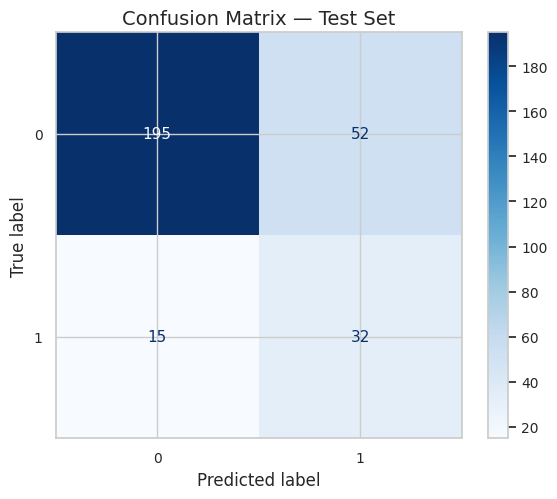

TN=195 FP=52 FN=15 TP=32


In [3]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues")
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"TN={tn} FP={fp} FN={fn} TP={tp}")

**Business Interpretation:** False negatives (missed leavers) are the costliest error for HR. Recall of ~0.68 means roughly one-third of leavers are missed at default threshold.

## 4. Classification Report

In [4]:
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.93      0.79      0.85       247
         Yes       0.38      0.68      0.49        47

    accuracy                           0.77       294
   macro avg       0.65      0.74      0.67       294
weighted avg       0.84      0.77      0.80       294



## 5. ROC Curve

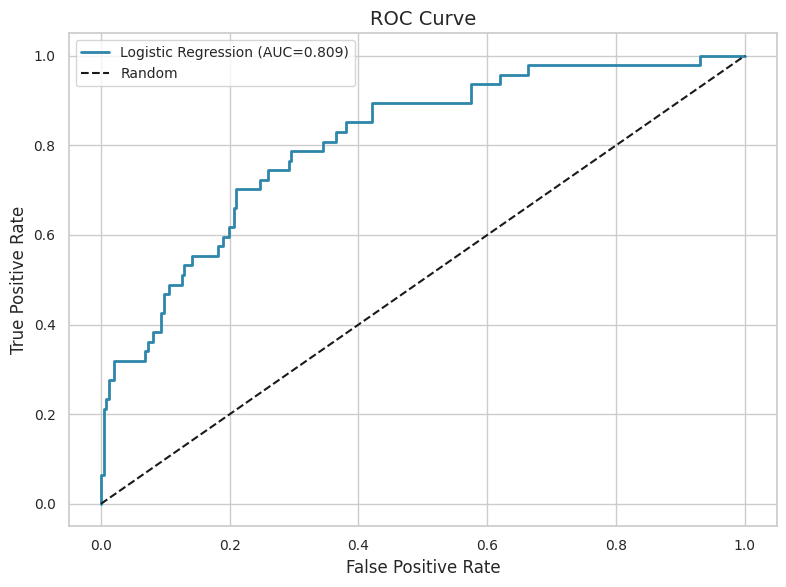

In [5]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, label=f"Logistic Regression (AUC={auc:.3f})", color="#2E86AB", linewidth=2)
ax.plot([0, 1], [0, 1], "k--", label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()
plt.tight_layout()
plt.show()

**Objective:** Assess ranking quality across classification thresholds.

**Interpretation:** AUC above 0.80 indicates strong separation between leavers and stayers.

**Business Insight:** The model ranks at-risk employees effectively; threshold can be tuned to trade precision for recall.


## 6. Precision-Recall Curve

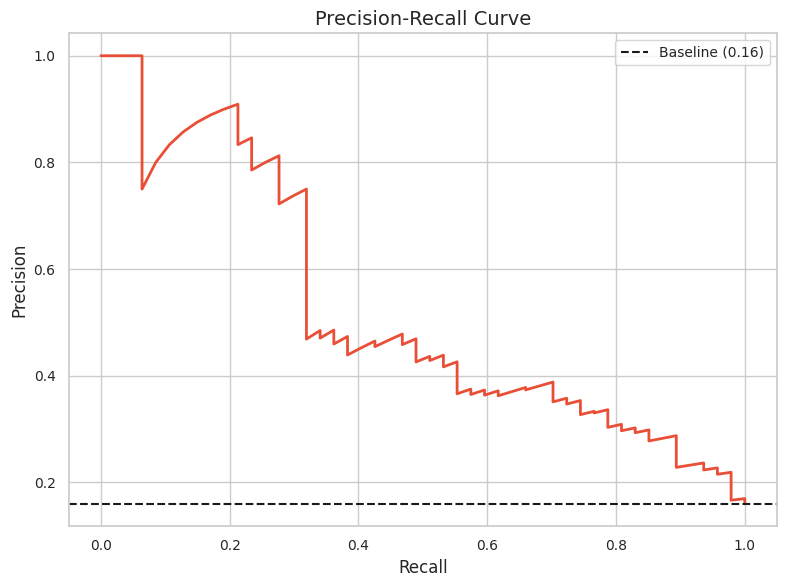

In [6]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
baseline = (y_test == 1).mean()
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall, precision, color="#E94F37", linewidth=2)
ax.axhline(baseline, color="k", linestyle="--", label=f"Baseline ({baseline:.2f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend()
plt.tight_layout()
plt.show()

**Objective:** Evaluate performance under class imbalance (16% positive rate).

**Interpretation:** The curve stays above the prevalence baseline, confirming lift over random flagging.

**Business Insight:** At operational recall targets, expect moderate precision — retention outreach will include false positives.


## 7. Feature Coefficients

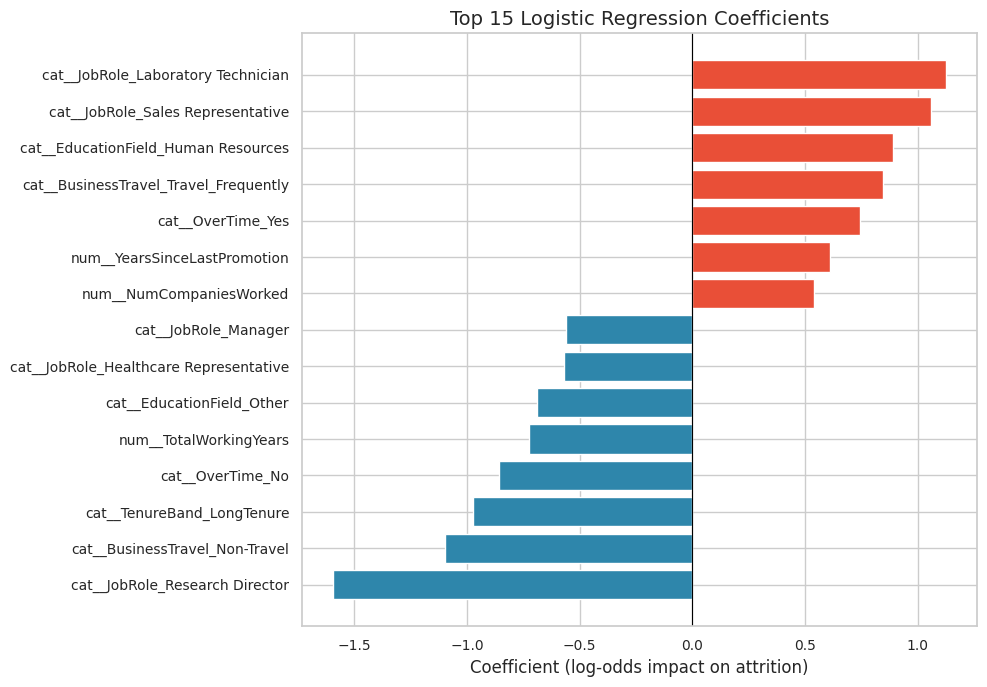

,Feature,Coefficient,AbsCoefficient
48,cat__JobRole_Research Director,-1.594106,1.594106
29,cat__BusinessTravel_Non-Travel,-1.098199,1.098199
61,cat__TenureBand_LongTenure,-0.972160,0.972160
55,cat__OverTime_No,-0.859470,0.859470
16,num__TotalWorkingYears,-0.725670,0.725670
39,cat__EducationField_Other,-0.691390,0.691390
43,cat__JobRole_Healthcare Representative,-0.570330,0.570330
46,cat__JobRole_Manager,-0.561721,0.561721
11,num__NumCompaniesWorked,0.540630,0.540630
21,num__YearsSinceLastPromotion,0.610643,0.610643


In [7]:
fig, coef_df = plot_coefficients(pipeline, top_n=15)
plt.show()
coef_df

**Business Interpretation:** Positive coefficients (e.g., OverTime, low satisfaction) increase attrition odds; protective factors include tenure and stock options.

## 8. Key Findings and Recommendations

In [8]:
findings = {
    "ROC-AUC": round(float(metrics_df["ROC-AUC"].iloc[0]), 3),
    "Recall": round(float(metrics_df["Recall"].iloc[0]), 3),
    "False Negatives": int(fn),
    "Top risk drivers": "OverTime, low satisfaction, early tenure",
    "Protective factors": "StockOptionLevel, TotalWorkingYears, Age",
}
recommendations = pd.DataFrame([
    {"Priority": "High", "Action": "Review overtime policy for at-risk employees"},
    {"Priority": "High", "Action": "Target retention programs at early-career cohorts"},
    {"Priority": "Medium", "Action": "Benchmark compensation for below-market roles"},
    {"Priority": "Medium", "Action": "Expand stock option eligibility"},
])
print("=== Phase 1 Baseline Performance ===")
for k, v in findings.items():
    print(f"  {k}: {v}")
recommendations

=== Phase 1 Baseline Performance ===
  ROC-AUC: 0.808
  Recall: 0.681
  False Negatives: 15
  Top risk drivers: OverTime, low satisfaction, early tenure
  Protective factors: StockOptionLevel, TotalWorkingYears, Age


,Priority,Action
0,High,Review overtime policy for at-risk employees
1,High,Target retention programs at early-career cohorts
2,Medium,Benchmark compensation for below-market roles
3,Medium,Expand stock option eligibility


## 9. Model Limitations

| Limitation | Impact | Future Mitigation |
|------------|--------|-------------------|
| Linear boundary | Misses interactions | Phase 2 ensembles (NB06) |
| Class imbalance | Low precision | Threshold tuning, SMOTE (Phase 2) |
| Likert as numeric | Ordinal info lost | Ordinal encoding |
| Single company data | Generalization risk | External validation |
| No explainability beyond coefficients | Limited trust | SHAP (NB08) |

## 10. Future Improvements

- **Notebook 06:** Model comparison (RF, XGBoost, LightGBM)
- **Notebook 07:** CTGAN synthetic data
- **Notebook 08:** SHAP explainability
- **Notebook 09:** Deployment (FastAPI, Streamlit)

See [PROJECT_GUIDE.md](../PROJECT_GUIDE.md).

## Conclusion

Phase 1 delivers an interpretable baseline with ROC-AUC ~0.81 and recall ~0.68. The model is suitable for academic review and provides a foundation for future production evolution.

## Future Connection

Phase 2 (Notebook 06) will compare ensemble models via the `src/` pipeline. Phase 1 establishes the interpretable baseline and evaluation framework for that comparison.
